# 05 — Modèles d'ensemble, apport par bloc, interprétation SHAP

Trois questions :

1. Les modèles non linéaires (random forest, gradient boosting) battent-ils la régression
   logistique ?
2. Quelle part du signal vient de la démographie seule, et combien l'alimentation puis le
   mode de vie ajoutent-ils par-dessus ?
3. Qu'est-ce que le modèle regarde, concrètement ?

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 60)
import joblib
from sklearn.model_selection import cross_val_score
from src import features, modeling, plotting
d = joblib.load(ROOT / "models" / "baseline_logit.joblib")
X_tr, y_tr, X_te, y_te = d["X_tr"], d["y_tr"], d["X_te"], d["y_te"]
df = pd.read_parquet(ROOT / "data" / "processed" / "analytique.parquet")
X, y = features.matrice_X_y(df)

In [2]:
tab = modeling.comparer(modeling.modeles(), X_tr, y_tr)
tab

,AP (PR-AUC),AP ± σ,ROC AUC,Brier
modèle,,,,
Régression logistique,0.4712,0.0191,0.6770,0.2270
Random forest,0.4605,0.0193,0.6702,0.2089
Gradient boosting,0.4364,0.0305,0.6536,0.2123


Les trois modèles se tiennent dans un mouchoir de poche, et la **régression logistique
reste devant** sur l'average precision. Ce n'est pas un accident : quand le signal est
faible et à peu près monotone, les arbres captent surtout du bruit. C'est un bon rappel
que « modèle plus complexe » n'égale pas « meilleur ».

In [3]:
# Apport incrémental des blocs de variables (régression logistique, CV 5 plis).
blocs = {
    "Démographie seule":
        (["age", "ratio_revenu"], ["sexe", "origine", "education"]),
    "+ alimentation":
        (["age", "ratio_revenu", "energie_kcal", "fibres_pour_1000kcal", "sucres_pct_kcal",
          "sodium_pour_1000kcal", "ratio_agpi_ags", "pct_lipides", "cholesterol_alim_mg",
          "cafeine_mg"], ["sexe", "origine", "education"]),
    "+ mode de vie":
        (["age", "ratio_revenu", "energie_kcal", "fibres_pour_1000kcal", "sucres_pct_kcal",
          "sodium_pour_1000kcal", "ratio_agpi_ags", "pct_lipides", "cholesterol_alim_mg",
          "cafeine_mg", "activite_met_min_sem", "sedentaire_min_j", "alcool_verres_sem",
          "sommeil_h"],
         ["sexe", "origine", "education", "statut_tabac", "transport_actif"]),
}
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

lignes = []
for nom, (num, cat) in blocs.items():
    pre = ColumnTransformer([
        ("n", Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]), num),
        ("c", Pipeline([("i", SimpleImputer(strategy="most_frequent")),
                        ("o", OneHotEncoder(handle_unknown="ignore", min_frequency=20))]), cat),
    ])
    pipe = Pipeline([("p", pre), ("m", LogisticRegression(max_iter=2000, class_weight="balanced"))])
    roc = cross_val_score(pipe, X, y, cv=modeling.CV, scoring="roc_auc")
    ap = cross_val_score(pipe, X, y, cv=modeling.CV, scoring="average_precision")
    lignes.append({"bloc": nom, "ROC AUC": roc.mean(), "AP": ap.mean()})

apport = pd.DataFrame(lignes).set_index("bloc").round(4)
apport

,ROC AUC,AP
bloc,,
Démographie seule,0.6651,0.4477
+ alimentation,0.6662,0.4554
+ mode de vie,0.6724,0.4604


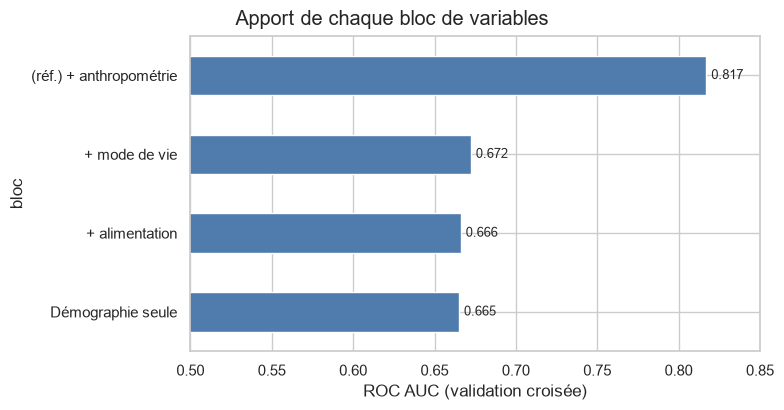

,ROC AUC,AP
bloc,,
Démographie seule,0.665,0.448
+ alimentation,0.666,0.455
+ mode de vie,0.672,0.460
(réf.) + anthropométrie,0.817,0.634


In [4]:
# Pour situer : et si on s'autorisait l'anthropométrie (IMC + tour de taille) ?
Xa = df.loc[df["cible"].notna(), ["age", "ratio_revenu", "imc", "tour_taille_cm", "sexe"]]
pre = ColumnTransformer([
    ("n", Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]),
     ["age", "ratio_revenu", "imc", "tour_taille_cm"]),
    ("c", OneHotEncoder(handle_unknown="ignore"), ["sexe"]),
])
pipe = Pipeline([("p", pre), ("m", LogisticRegression(max_iter=2000, class_weight="balanced"))])
roc_plafond = cross_val_score(pipe, Xa, y, cv=modeling.CV, scoring="roc_auc").mean()
apport.loc["(réf.) + anthropométrie"] = [roc_plafond,
    cross_val_score(pipe, Xa, y, cv=modeling.CV, scoring="average_precision").mean()]
fig = plotting.apport_par_bloc(apport)
fig.suptitle("Apport de chaque bloc de variables", y=1.02)
plotting.save(fig, "05_apport_par_bloc")
plt.show()
apport.round(3)

C'est le résultat central du projet.

- La **démographie seule** (âge, sexe, origine, éducation, revenu) atteint déjà ROC ≈ 0,66.
- **L'alimentation déclarée** n'ajoute quasiment rien par-dessus (+0,00 à 0,01).
- **Le mode de vie** (activité, sédentarité, tabac, alcool, sommeil) ajoute un petit
  quelque chose de plus, ROC ≈ 0,67.
- Dès qu'on s'autorise le **tour de taille et l'IMC**, on saute à ROC ≈ 0,82 — mais ces
  variables sont à moitié la définition de la cible, donc ce chiffre est juste un repère
  haut, pas un modèle honnête.

Autrement dit : **à âge et catégorie sociale donnés, ce que les gens déclarent manger et
faire n'explique presque pas qui développera un syndrome métabolique.** Ça ne veut pas dire
que l'alimentation ne compte pas biologiquement — ça veut dire que deux rappels de 24 h
sont un instrument trop grossier pour le voir, et que le gros du risque prédictible est
déjà porté par l'âge et l'anthropométrie.

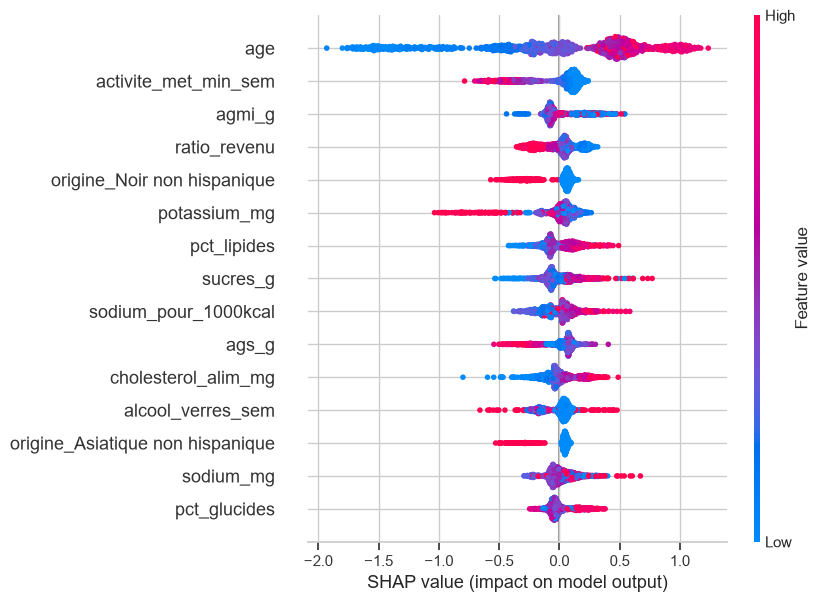

In [5]:
# SHAP sur le gradient boosting (le modèle non linéaire le plus régulier).
import shap
gb = modeling.modeles()["Gradient boosting"]
gb.fit(X_tr, y_tr)
prep = gb.named_steps["prep"]
X_te_mat = prep.transform(X_te)
noms = prep.get_feature_names_out()
expl = shap.TreeExplainer(gb.named_steps["clf"])
sv = expl.shap_values(X_te_mat)
shap.summary_plot(sv, X_te_mat, feature_names=[n.split("__")[-1] for n in noms],
                  max_display=15, show=False)
fig = plt.gcf(); fig.set_size_inches(9, 6)
plotting.save(fig, "05_shap_summary")
plt.show()

SHAP raconte la même histoire que les coefficients : l'âge écrase tout, puis viennent le
sexe, l'origine, la sédentarité et quelques marqueurs alimentaires (fibres, sucres) avec
des contributions faibles et le signe attendu.

In [6]:
# Évaluation finale sur le test, mis de côté depuis le notebook 04.
from src import plotting
final = {}
for nom in ["Régression logistique", "Gradient boosting"]:
    p = modeling.modeles()[nom]
    perf = modeling.evaluer_test(p, X_tr, y_tr, X_te, y_te)
    final[nom] = perf
res_test = pd.DataFrame(final).T.round(3)
res_test.to_csv(ROOT / "results" / "tables" / "05_performance_test.csv")
res_test

,AP (PR-AUC),ROC AUC,Brier,rappel@top10%,lift@top10%,rappel@top20%,lift@top20%,rappel@top30%,lift@top30%
Régression logistique,0.442,0.658,0.231,0.139,1.388,0.291,1.457,0.434,1.446
Gradient boosting,0.435,0.649,0.212,0.136,1.366,0.277,1.388,0.414,1.377


Sur le jeu de test, les deux modèles se valent (AUC ≈ 0,65). Lecture plus concrète avec le
**lift** : en ciblant les 20 % de personnes jugées les plus à risque, on y trouve environ 1,4 à 1,5 fois plus de cas que dans la population générale, et on capture un peu moins d'un tiers
de tous les cas. C'est le genre de performance qui peut servir à prioriser un dépistage, pas
à poser un diagnostic.

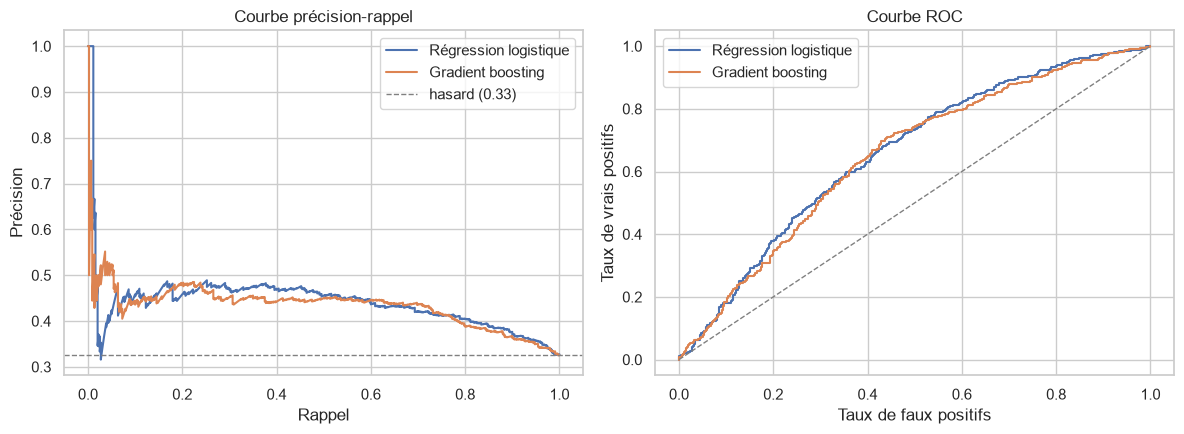

In [7]:
scores = {}
for nom in ["Régression logistique", "Gradient boosting"]:
    p = modeling.modeles()[nom]; p.fit(X_tr, y_tr)
    scores[nom] = (y_te.values, p.predict_proba(X_te)[:, 1])
fig = plotting.courbes_pr_roc(scores)
plotting.save(fig, "05_pr_roc_test")
plt.show()